# 6CS012 : Final Portfolio Assessment 2026
## Part II: Brain Tumor Image Classification with CNNs


#### **Student ID**: 2408863
#### **Full Name** : Prabesh Raj Maharjan
#### **Dataset**: Brain Tumor Classification (MRI Scans)
#### **Classes**: glioma_tumor, meningioma_tumor, pituitary_tumor & normal
#### **Total Samples**: 3,096 (2,475 train / 621 test)
#### **Image Size** : 256 × 256 px
#### **Class Balance** : 52.4% not sarcastic & 47.6% sarcasti

----

### Dataset Summary
This dataset contains MRI brain scan images labelled across 4 classes:
- **glioma_tumor** : 720 train / 181 test
- **meningioma_tumor** : 730 train / 183 test
- **pituitary_tumor** : 675 train / 169 test
- **normal** : 350 train / 88 test (class imbalance noted)

  **Note:** 28 corrupt image files were detected and are handled with a custom data loader below.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


## Step 0 Google Colab Setup & Dataset Upload

In [ ]:
# #  Run this cell first on Google Colab
# # Upload your Brain_Tumor_Classifcation.zip using the Files panel (left sidebar)
# # Then run:

# import zipfile, os

# ZIP_PATH = 'Brain_Tumor_Classifcation.zip'   # adjust if filename differs

# if os.path.exists(ZIP_PATH):
#     with zipfile.ZipFile(ZIP_PATH, 'r') as z:
#         z.extractall('brain_tumor')
#     print('Dataset extracted successfully.')
# else:
#     print(f'ZIP not found at {ZIP_PATH}. Please upload it first.')

## Step 1: Imports & Global Configuration

In [ ]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#  Dataset Config (exact paths from your zip)
BASE_DIR  = '/content/drive/MyDrive/Ai and Machine Learning/brain tumor/Brain Tumor Classifcation/train'
TEST_DIR  = '/content/drive/MyDrive/Ai and Machine Learning/brain tumor/Brain Tumor Classifcation/test'

#  Model Config
IMG_SIZE    = (128, 128)    # resized from 256x256 for faster training
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']

EPOCHS_BASELINE = 25
EPOCHS_DEEP     = 30
EPOCHS_TL       = 20

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Classes      : {CLASS_NAMES}')

TensorFlow  : 2.20.0
GPU available: True
Classes      : ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


## Step 2: Data Understanding, Analysis & Visualisation

REMOVING CORRUPTED IMAGES...

✅ Removed 0 corrupted images

Counting training set images...
Counting test set images...

=== TRAIN SET ===
  glioma_tumor          : 713 images
  meningioma_tumor      : 723 images
  normal                : 343 images
  pituitary_tumor       : 668 images
  Total            : 2447

=== TEST SET ===
  glioma_tumor          : 181 images
  meningioma_tumor      : 182 images
  normal                : 88 images
  pituitary_tumor       : 169 images
  Total            : 620


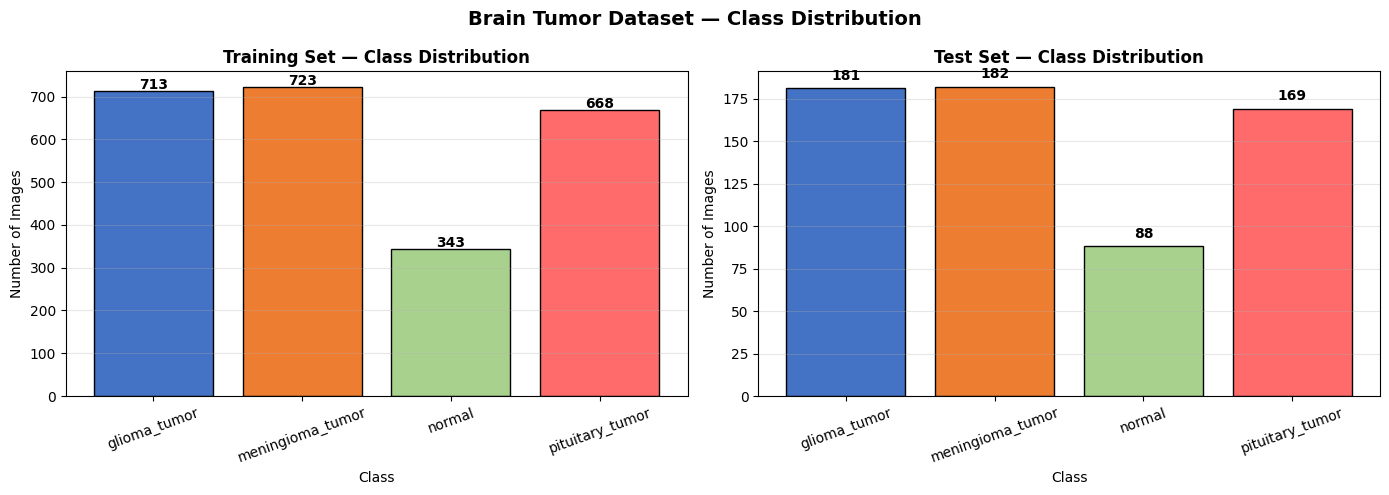

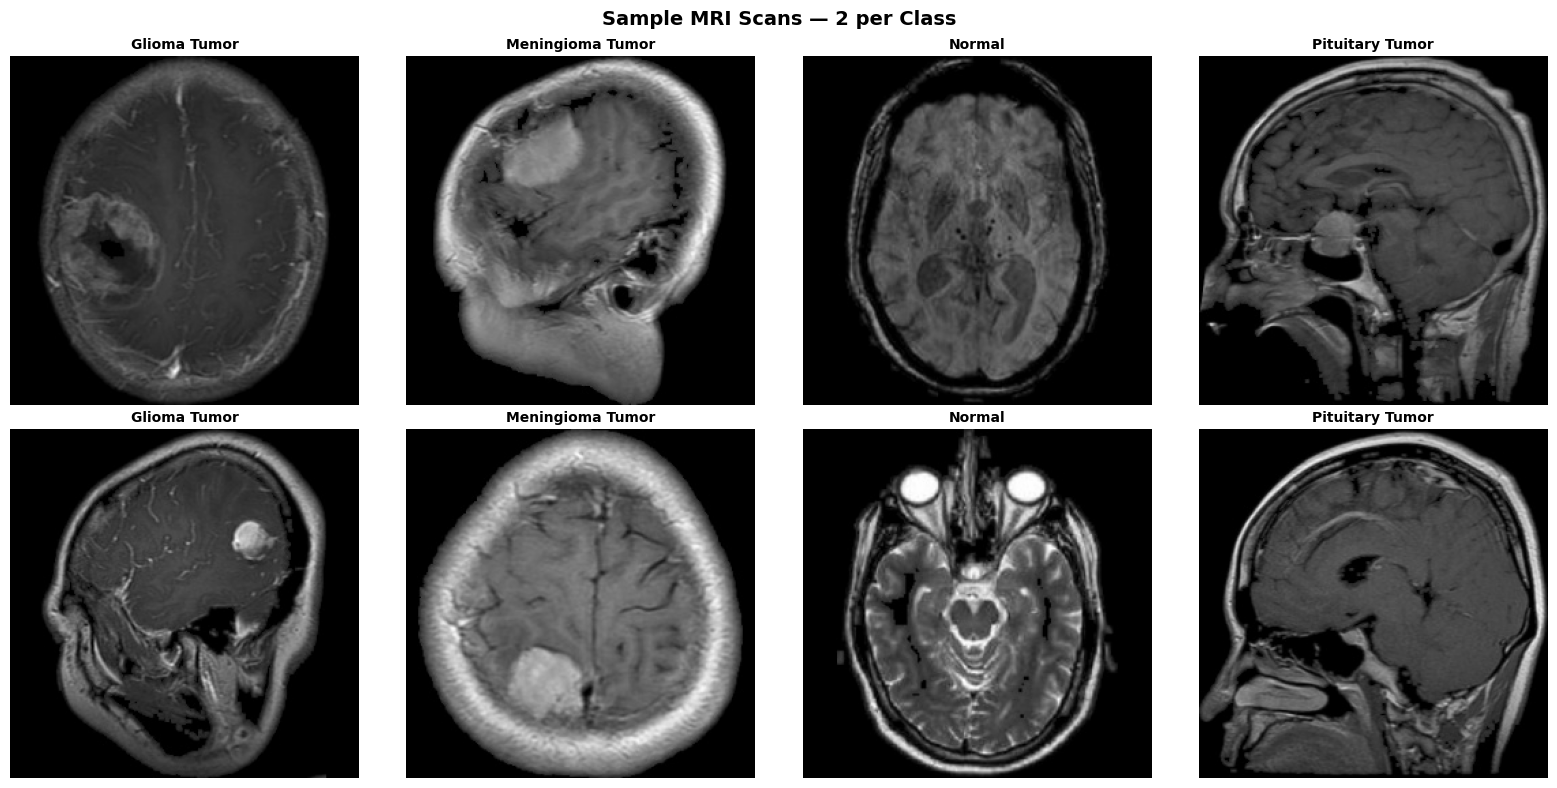

In [ ]:

#  Step 2: Data Understanding, Analysis & Visualisation
# THIS REPLACES your entire Step 2 cell

from PIL import Image
import os
import matplotlib.pyplot as plt

# FIRST: Remove corrupted images permanently
print("="*50)
print("REMOVING CORRUPTED IMAGES...")
print("="*50)

corrupted_count = 0
for directory in [BASE_DIR, TEST_DIR]:
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except Exception:
                    print(f"Removing corrupted: {file_path}")
                    os.remove(file_path)
                    corrupted_count += 1

print(f"\n Removed {corrupted_count} corrupted images\n")

# NOW count the valid images
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        valid = 0
        for f in os.listdir(cls_path):
            fpath = os.path.join(cls_path, f)
            try:
                img = Image.open(fpath)
                img.verify()
                valid += 1
            except:
                continue  # Skip any remaining corrupted files
        counts[cls] = valid
    return counts

print("Counting training set images...")
train_counts = count_images(BASE_DIR)
print("Counting test set images...")
test_counts = count_images(TEST_DIR)

print(f'\n=== TRAIN SET ===')
for cls, cnt in train_counts.items():
    print(f'  {cls:<22}: {cnt} images')
print(f'  Total            : {sum(train_counts.values())}')

print(f'\n=== TEST SET ===')
for cls, cnt in test_counts.items():
    print(f'  {cls:<22}: {cnt} images')
print(f'  Total            : {sum(test_counts.values())}')

# Class distribution chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF6B6B']

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set — Class Distribution', 'Test Set — Class Distribution']
):
    classes = list(counts.keys())
    values  = list(counts.values())
    bars = ax.bar(classes, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5, str(val),
                ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Brain Tumor Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col_idx, cls in enumerate(sorted(train_counts.keys())):
    cls_path = os.path.join(BASE_DIR, cls)
    images_shown = 0
    for fname in os.listdir(cls_path):
        if images_shown >= 2:
            break
        try:
            img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
            axes[images_shown][col_idx].imshow(img, cmap='gray')
            axes[images_shown][col_idx].set_title(
                cls.replace('_', ' ').title(), fontsize=10, fontweight='bold'
            )
            axes[images_shown][col_idx].axis('off')
            images_shown += 1
        except:
            continue

plt.suptitle('Sample MRI Scans — 2 per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

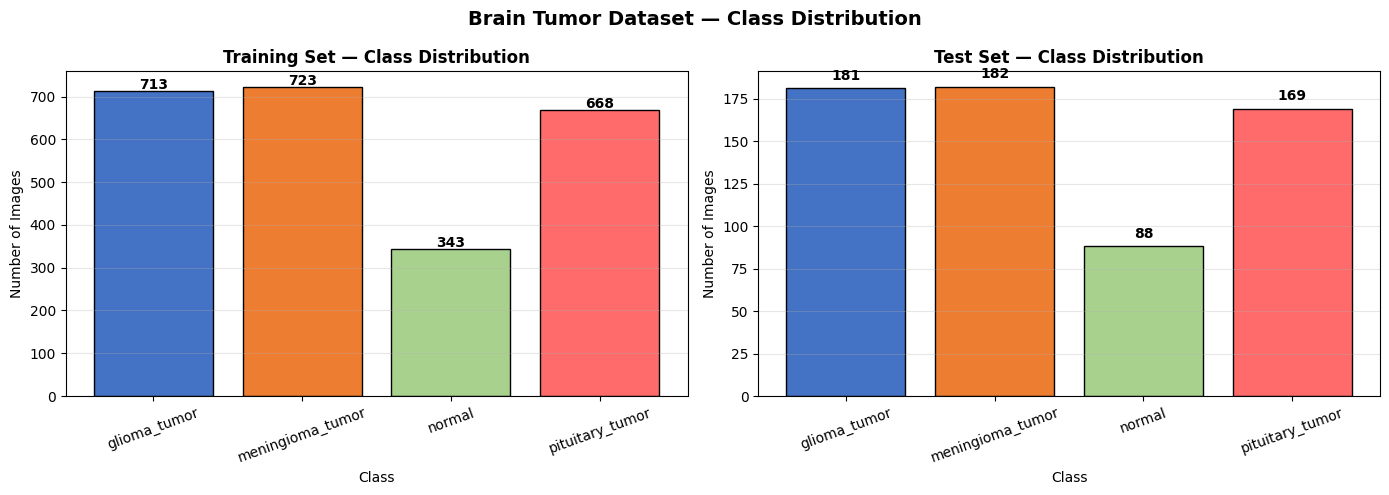


Observation: "normal" class has ~50% fewer images than tumor classes.
Solution: class_weight parameter used during training to compensate.


In [ ]:
# Class Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF6B6B']

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set — Class Distribution', 'Test Set — Class Distribution']
):
    classes = list(counts.keys())
    values  = list(counts.values())
    bars = ax.bar(classes, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5, str(val),
                ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Brain Tumor Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nObservation: "normal" class has ~50% fewer images than tumor classes.')
print('Solution: class_weight parameter used during training to compensate.')

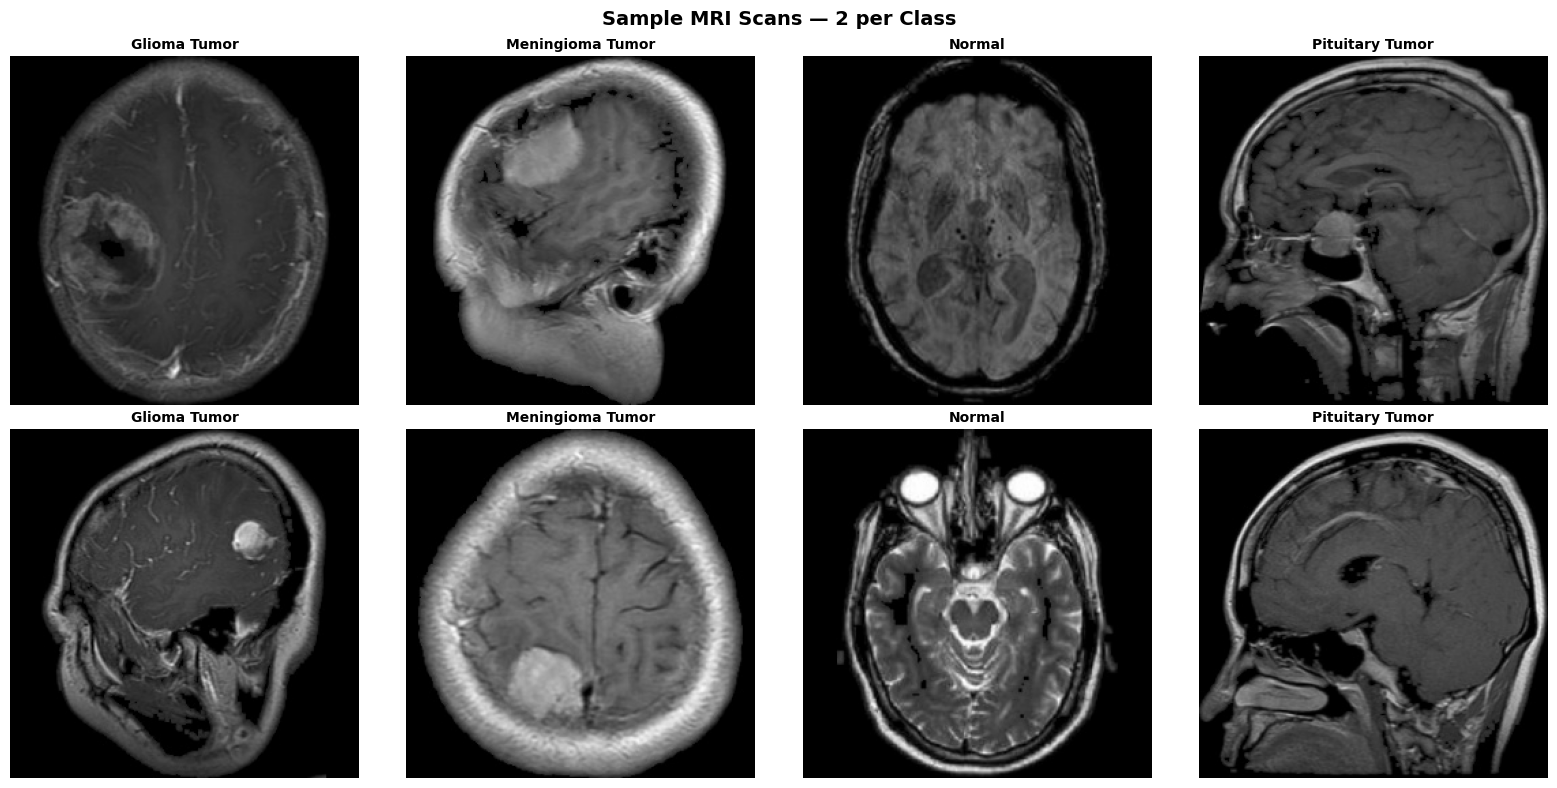

In [ ]:
# Sample Images from Each Class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col_idx, cls in enumerate(sorted(train_counts.keys())):
    cls_path = os.path.join(BASE_DIR, cls)
    images_shown = 0
    for fname in os.listdir(cls_path):
        if images_shown >= 2:
            break
        try:
            img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
            axes[images_shown][col_idx].imshow(img, cmap='gray')
            axes[images_shown][col_idx].set_title(
                cls.replace('_', ' ').title(), fontsize=10, fontweight='bold'
            )
            axes[images_shown][col_idx].axis('off')
            images_shown += 1
        except:
            continue

plt.suptitle('Sample MRI Scans — 2 per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 : Preprocessing, Augmentation & Data Generators

In [ ]:
# Training Generator with Augmentation
# Augmentation helps because we only have ~2,475 training images
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,         # MRI scans can be rotated slightly
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.15      # 15% of training for validation
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
val_gen = train_datagen.flow_from_directory(
    BASE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(f'Train samples : {train_gen.samples}')
print(f'Val samples   : {val_gen.samples}')
print(f'Test samples  : {test_gen.samples}')
print(f'Class indices : {train_gen.class_indices}')

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 620 images belonging to 4 classes.
Train samples : 2082
Val samples   : 365
Test samples  : 620
Class indices : {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}


In [ ]:
#Compute Class Weights (handles imbalance: normal has fewer samples)
labels_array = train_gen.classes
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weight_dict = dict(enumerate(class_weights_values))
print('Class weights (to handle imbalance):')
for idx, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights_values)):
    print(f'  Class {idx} ({cls:<22}): weight = {w:.4f}')

Class weights (to handle imbalance):
  Class 0 (glioma_tumor          ): weight = 0.8575
  Class 1 (meningioma_tumor      ): weight = 0.8463
  Class 2 (normal                ): weight = 1.7825
  Class 3 (pituitary_tumor       ): weight = 0.9164


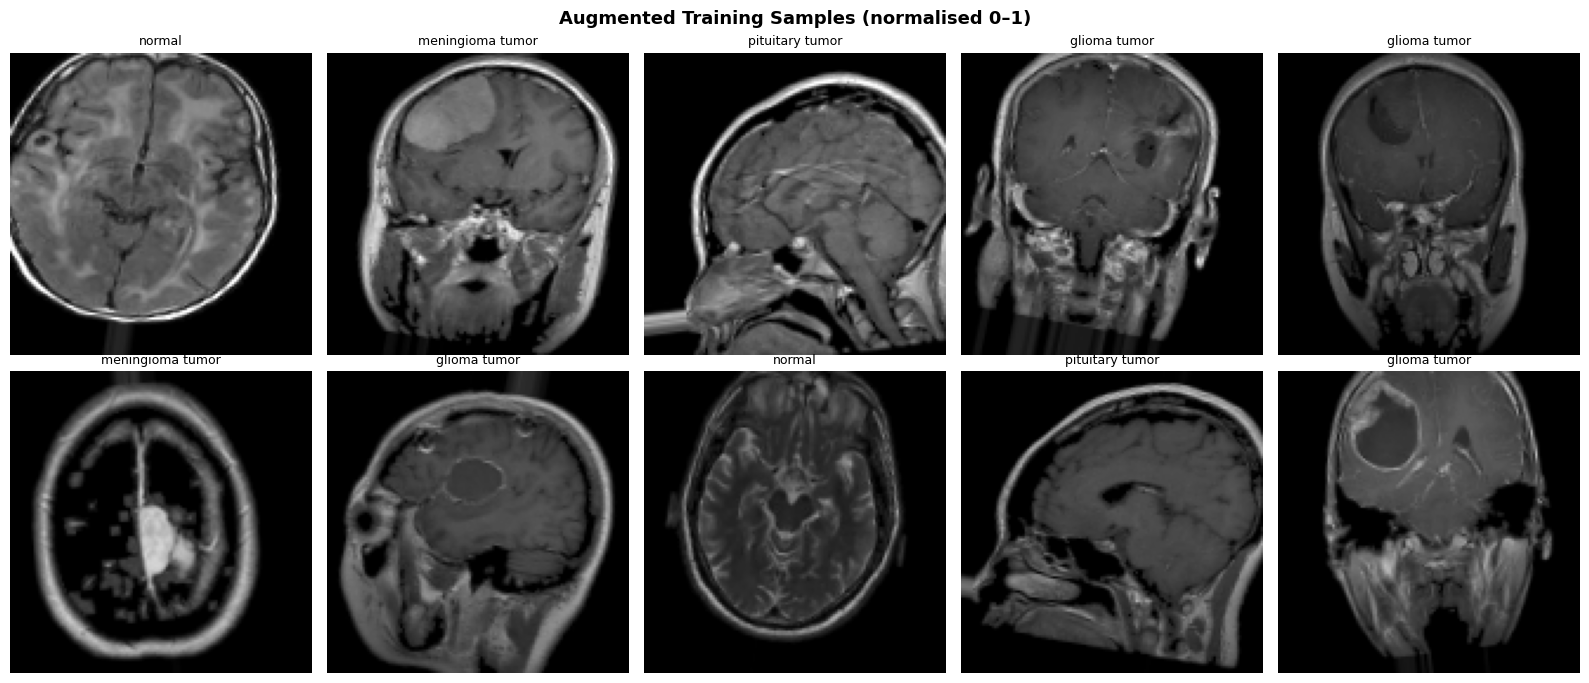

In [ ]:
# Visualise Augmented Samples
sample_imgs, sample_lbls = next(train_gen)
label_map = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i], cmap='gray')
    ax.set_title(label_map[np.argmax(sample_lbls[i])].replace('_',' '), fontsize=9)
    ax.axis('off')

plt.suptitle('Augmented Training Samples (normalised 0–1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 : Helper Functions

In [ ]:
def plot_history(history, title='Training History', save_name=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],         label='Train Loss',  linewidth=2)
    ax1.plot(history.history['val_loss'],     label='Val Loss',    linewidth=2, linestyle='--')
    ax1.set_title('Loss Curves');  ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train Acc',   linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val Acc',     linewidth=2, linestyle='--')
    ax2.set_title('Accuracy Curves'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_name: plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    #  Bias-Variance Analysis
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    print(f'\n--- Bias-Variance Analysis ---')
    print(f'Final Train Accuracy : {final_train_acc:.4f}')
    print(f'Final Val   Accuracy : {final_val_acc:.4f}')
    print(f'Gap (Train - Val)    : {gap:.4f}')
    if gap > 0.10:
        print('>> HIGH VARIANCE (Overfitting) — model memorising training data')
    elif final_train_acc < 0.75:
        print('>> HIGH BIAS (Underfitting) — model too simple')
    else:
        print('>> GOOD FIT — train and val accuracy are close')


def evaluate_model(model, generator, model_name='Model'):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'\n{model_name}')
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')

    generator.reset()
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.xticks(rotation=25); plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    return loss, acc

print('Helper functions ready.')

Helper functions ready.


## Step 5: Part A: Baseline CNN (3 Conv + 3 FC layers)

In [ ]:

# BASELINE CNN
# Architecture: 3 x (Conv2D → MaxPool)  Flatten  3 x Dense  Softmax
# Kernel: 3x3, Filters: 32→64→128, Activation: ReLU

def build_baseline(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Baseline_CNN')

    # Conv Block 1: 32 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))

    # Conv Block 2: 64 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Conv Block 3: 128 filters, 3x3 kernel, ReLU
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))   # FC1
    model.add(layers.Dense(128, activation='relu'))   # FC2
    model.add(layers.Dense(64,  activation='relu'))   # FC3

    # Output layer: 4 classes, softmax
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline()
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('Training Baseline CNN...')
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASELINE,
    validation_data=val_gen,
    class_weight=class_weight_dict,   # handles normal class imbalance
    callbacks=callbacks_base,
    verbose=1
)
baseline_time = time.time() - t0
print(f'\nBaseline training time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')

Training Baseline CNN...
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 406ms/step - accuracy: 0.2925 - loss: 1.3391 - val_accuracy: 0.4356 - val_loss: 1.3099 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 388ms/step - accuracy: 0.4500 - loss: 1.1852 - val_accuracy: 0.5945 - val_loss: 1.0577 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 347ms/step - accuracy: 0.5159 - loss: 1.0544 - val_accuracy: 0.5753 - val_loss: 1.0115 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.5384 - loss: 1.0045 - val_accuracy: 0.6110 - val_loss: 0.9127 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 362ms/step - accuracy: 0.5980 - loss: 0.8746 - val_accuracy: 0.6164 - val_loss: 0.9365 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 341ms/step - accuracy: 0.6210 - loss: 0.8191 - val_accuracy: 0.6301 - val_loss: 0.8618 - learning_rate: 0.0010
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 336ms/step - ac

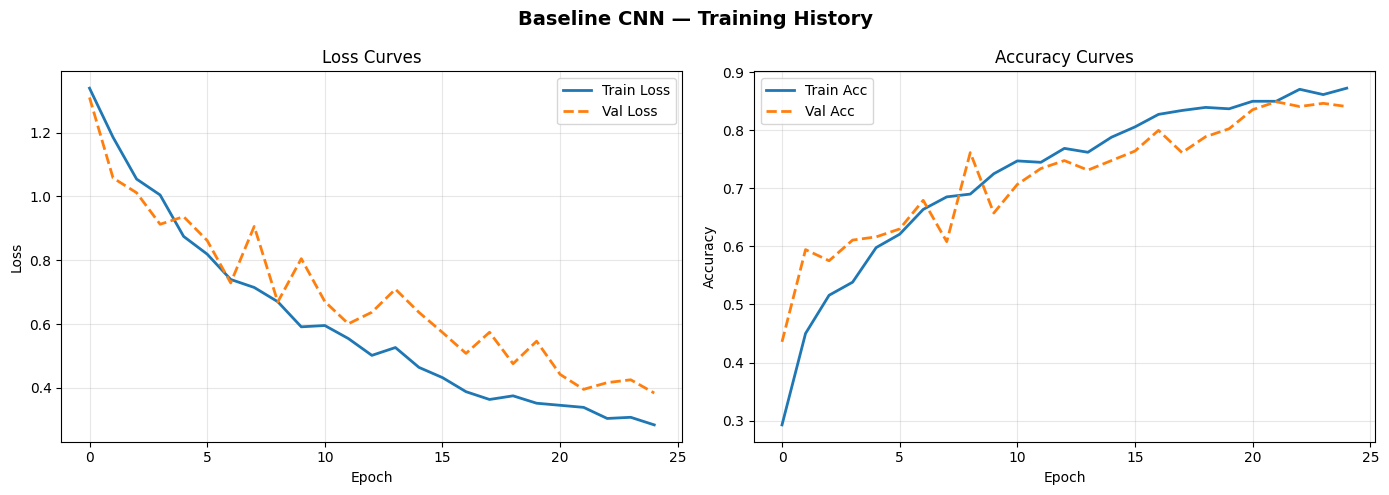


--- Bias-Variance Analysis ---
Final Train Accuracy : 0.8727
Final Val   Accuracy : 0.8411
Gap (Train - Val)    : 0.0316
>> GOOD FIT — train and val accuracy are close

Baseline CNN
  Test Loss     : 0.5349
  Test Accuracy : 0.8468 (84.68%)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.83      0.85       181
meningioma_tumor       0.84      0.76      0.80       182
          normal       0.89      0.80      0.84        88
 pituitary_tumor       0.81      0.99      0.89       169

        accuracy                           0.85       620
       macro avg       0.85      0.84      0.84       620
    weighted avg       0.85      0.85      0.84       620



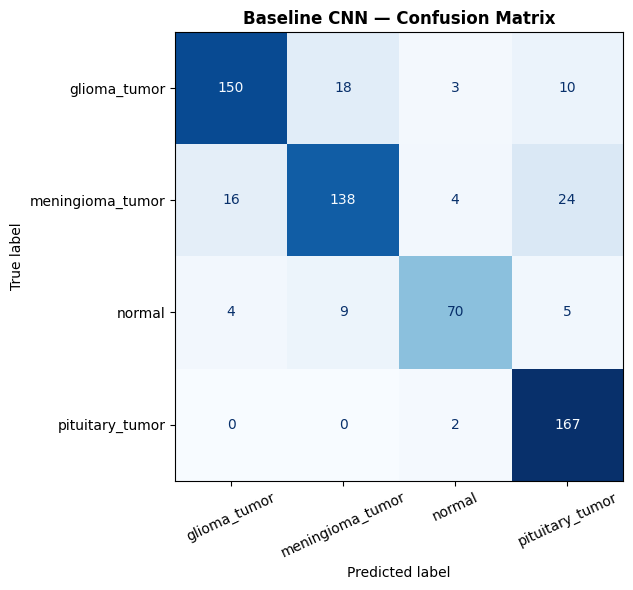

In [ ]:
plot_history(history_baseline, 'Baseline CNN — Training History', 'baseline_history.png')
baseline_loss, baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

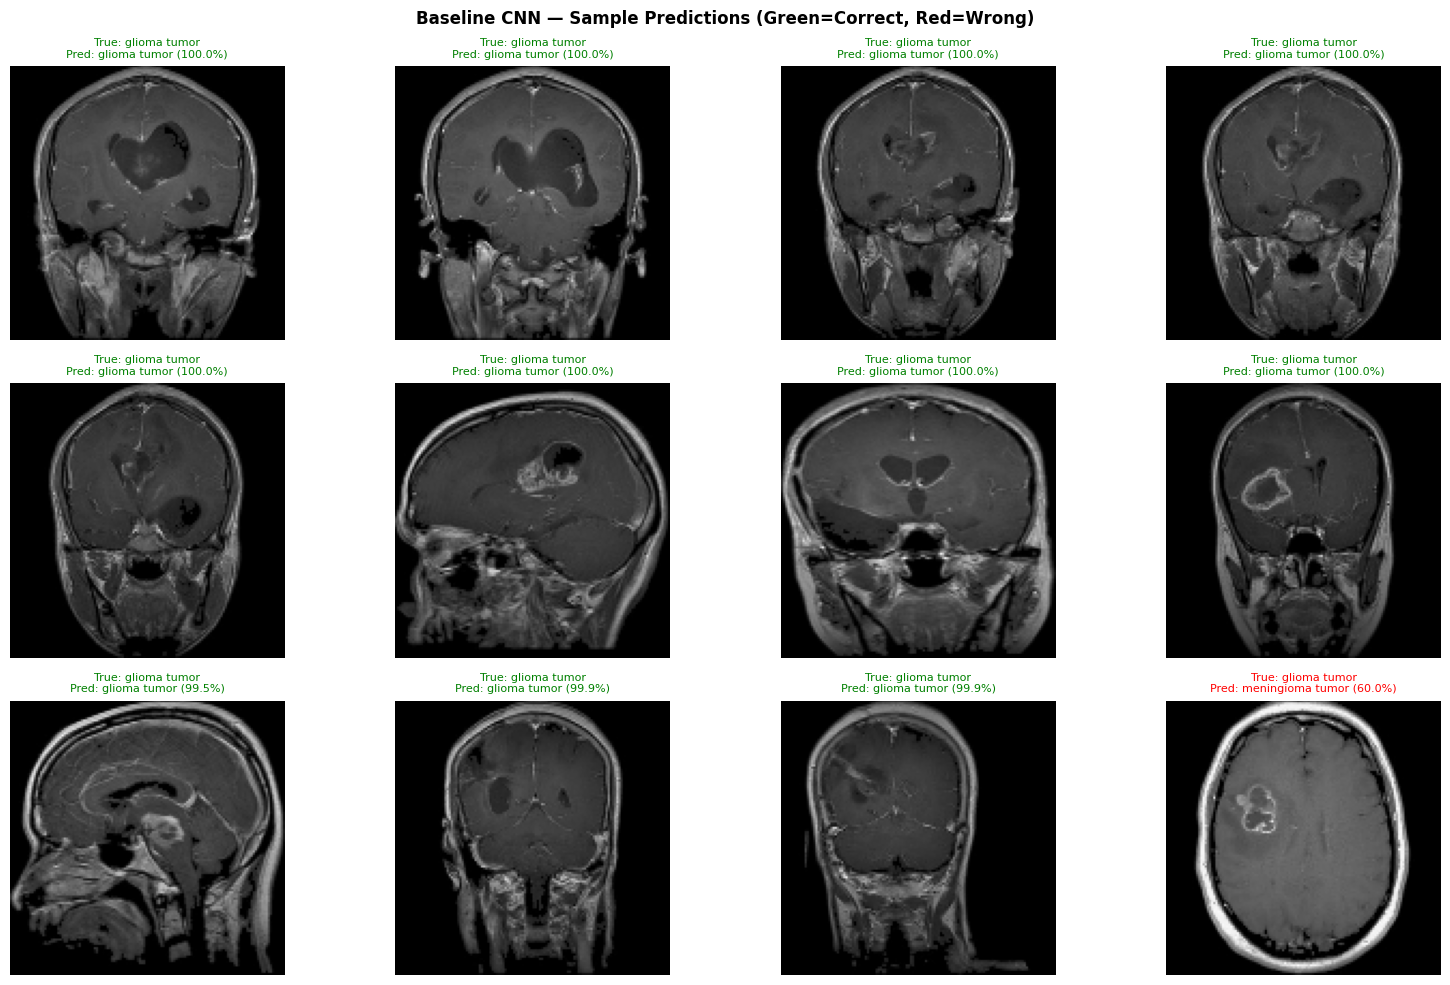

In [ ]:
# Visual Inference on Test Samples
test_gen.reset()
sample_imgs, sample_lbls = next(test_gen)
preds = baseline_model.predict(sample_imgs[:12], verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i], cmap='gray')
    true_cls = CLASS_NAMES[np.argmax(sample_lbls[i])].replace('_',' ')
    pred_cls = CLASS_NAMES[np.argmax(preds[i])].replace('_',' ')
    conf     = np.max(preds[i]) * 100
    color    = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                 fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Baseline CNN — Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Deeper CNN with BatchNorm + Dropout

In [ ]:

# DEEP CNN — 6 Conv blocks (double baseline) + BatchNorm + Dropout
# Regularisation: BatchNorm stabilises training, Dropout prevents overfitting

def build_deep_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Deep_CNN')

    # Block 1 — 32 filters
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2 — 64 filters
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3 — 128 filters
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # FCN Head with regularisation
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

deep_model_adam = build_deep_cnn()
deep_model_adam.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
      optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deep_model_adam.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           51

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
callbacks_deep = [
    # EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
      EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('Training Deep CNN (Adam)...')
t0 = time.time()
history_deep_adam = deep_model_adam.fit(
    train_gen, epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_deep, verbose=1
)
deep_adam_time = time.time() - t0
print(f'\nDeep CNN (Adam) time: {deep_adam_time:.1f}s ({deep_adam_time/60:.1f} min)')

Training Deep CNN (Adam)...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 544ms/step - accuracy: 0.3084 - loss: 1.6060 - val_accuracy: 0.2740 - val_loss: 1.7269 - learning_rate: 1.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 349ms/step - accuracy: 0.4030 - loss: 1.3309 - val_accuracy: 0.3863 - val_loss: 1.8560 - learning_rate: 1.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 339ms/step - accuracy: 0.4116 - loss: 1.3107 - val_accuracy: 0.2740 - val_loss: 2.1343 - learning_rate: 1.0000e-04
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4370 - loss: 1.2714
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 349ms/step - accuracy: 0.4539 - loss: 1.2528 - val_accuracy: 0.2740 - val_loss: 2.3015 - learning_rate: 1.0000e-04
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 340ms/step - accuracy: 0.4803 - loss: 1.1847 - val_accuracy: 0.2767 - val_loss: 2.1147 - learning_rate: 5.0000e-05
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━

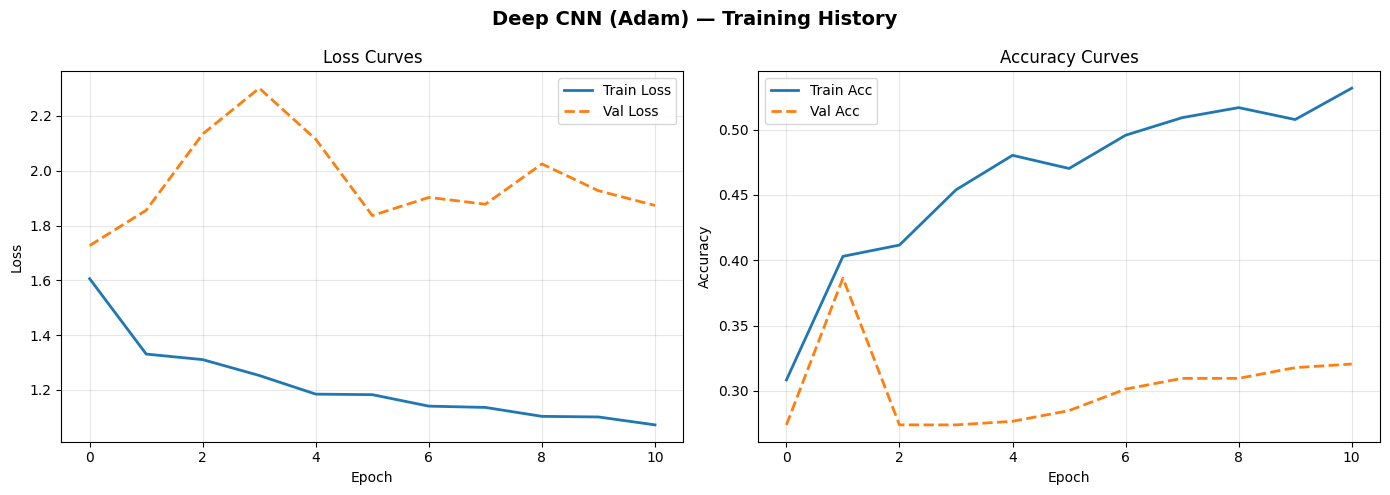


--- Bias-Variance Analysis ---
Final Train Accuracy : 0.5317
Final Val   Accuracy : 0.3205
Gap (Train - Val)    : 0.2112
>> HIGH VARIANCE (Overfitting) — model memorising training data

Deep CNN Adam
  Test Loss     : 1.7267
  Test Accuracy : 0.2726 (27.26%)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.00      0.00      0.00       182
          normal       0.00      0.00      0.00        88
 pituitary_tumor       0.27      1.00      0.43       169

        accuracy                           0.27       620
       macro avg       0.07      0.25      0.11       620
    weighted avg       0.07      0.27      0.12       620



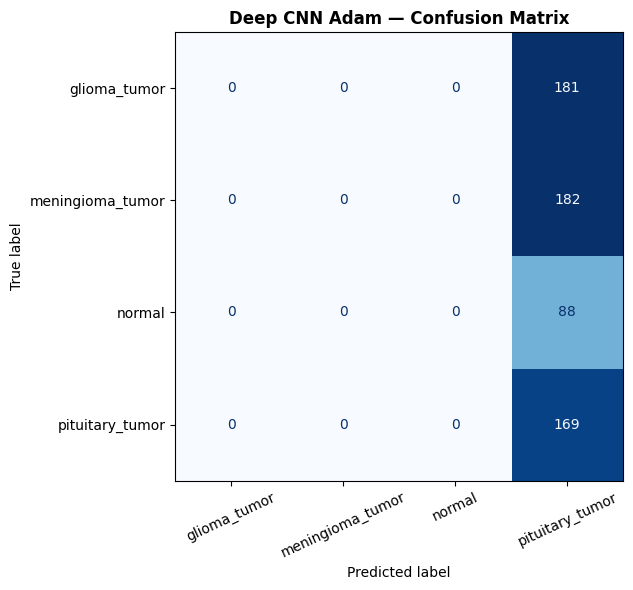

In [ ]:
plot_history(history_deep_adam, 'Deep CNN (Adam) — Training History', 'deep_adam_history.png')
deep_adam_loss, deep_adam_acc = evaluate_model(deep_model_adam, test_gen, 'Deep CNN Adam')

## Step 7 :Optimizer Comparison: Adam vs SGD

In [ ]:
deep_model_sgd = build_deep_cnn()
deep_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Deep CNN (SGD + Nesterov Momentum)...')
t0 = time.time()
history_deep_sgd = deep_model_sgd.fit(
    train_gen, epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_deep, verbose=1
)
deep_sgd_time = time.time() - t0
print(f'\nDeep CNN (SGD) time: {deep_sgd_time:.1f}s ({deep_sgd_time/60:.1f} min)')

Training Deep CNN (SGD + Nesterov Momentum)...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 473ms/step - accuracy: 0.3511 - loss: 1.4734 - val_accuracy: 0.1397 - val_loss: 2.7982 - learning_rate: 0.0100
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 345ms/step - accuracy: 0.4097 - loss: 1.2719 - val_accuracy: 0.1589 - val_loss: 1.6509 - learning_rate: 0.0100
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.4246 - loss: 1.2442 - val_accuracy: 0.2740 - val_loss: 1.5933 - learning_rate: 0.0100
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step - accuracy: 0.4664 - loss: 1.1952 - val_accuracy: 0.4603 - val_loss: 1.1200 - learning_rate: 0.0100
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 350ms/step - accuracy: 0.4712 - loss: 1.1228 - val_accuracy: 0.5534 - val_loss: 1.0707 - learning_rate: 0.0100
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 334ms/step - accuracy: 0.3963 - loss: 1.2457 - val_accuracy: 0.2877 - val_loss: 1.4175 - learning_rate: 0.0100
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━

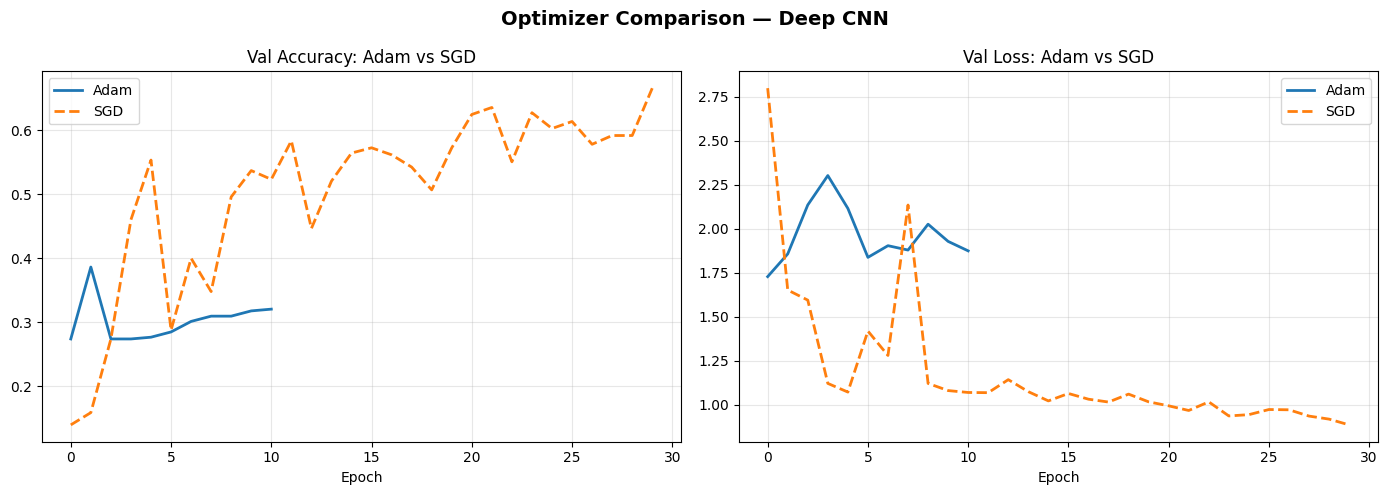


Deep CNN SGD
  Test Loss     : 0.8604
  Test Accuracy : 0.6290 (62.90%)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.70      0.65      0.67       181
meningioma_tumor       0.64      0.34      0.44       182
          normal       0.59      0.75      0.66        88
 pituitary_tumor       0.60      0.86      0.70       169

        accuracy                           0.63       620
       macro avg       0.63      0.65      0.62       620
    weighted avg       0.64      0.63      0.61       620



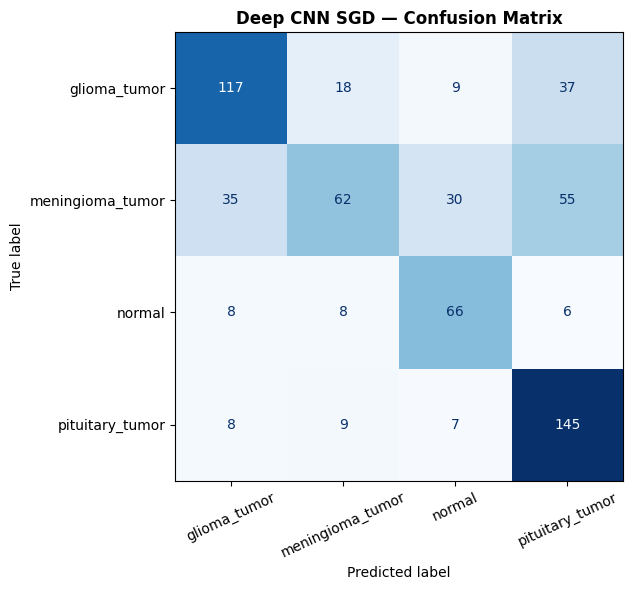

In [ ]:
# Side-by-side comparison plot ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep_adam.history['val_accuracy'], label='Adam', lw=2)
axes[0].plot(history_deep_sgd.history['val_accuracy'],  label='SGD',  lw=2, ls='--')
axes[0].set_title('Val Accuracy: Adam vs SGD'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deep_adam.history['val_loss'], label='Adam', lw=2)
axes[1].plot(history_deep_sgd.history['val_loss'],  label='SGD',  lw=2, ls='--')
axes[1].set_title('Val Loss: Adam vs SGD'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison — Deep CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

deep_sgd_loss, deep_sgd_acc = evaluate_model(deep_model_sgd, test_gen, 'Deep CNN SGD')

## Step 8 : Ablation Study: Remove BatchNormalization

Training Ablation Model (no BatchNorm)...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 450ms/step - accuracy: 0.2858 - loss: 1.3845 - val_accuracy: 0.4411 - val_loss: 1.3432 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 348ms/step - accuracy: 0.3007 - loss: 1.3488 - val_accuracy: 0.2904 - val_loss: 1.3675 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2900 - loss: 1.3869
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 369ms/step - accuracy: 0.2915 - loss: 1.3891 - val_accuracy: 0.2904 - val_loss: 1.3843 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 335ms/step - accuracy: 0.2800 - loss: 1.3866 - val_accuracy: 0.2904 - val_loss: 1.3852 - learning_rate: 5.0000e-04
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 350ms/step - accuracy: 0.2627 - loss: 1.3870 - val_accuracy: 0.2740 - val_loss: 1.3857 - learning_rate: 5.0000e-04
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━

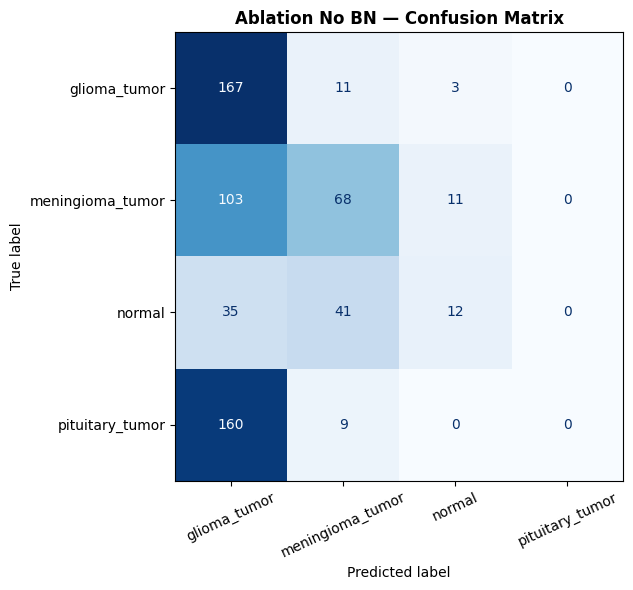


Ablation training time: 244.2s


In [ ]:
#  Same Deep CNN but WITHOUT BatchNormalization
# This shows the impact of BatchNorm on training stability and accuracy
def build_deep_no_bn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Deep_CNN_NoBN')
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.25))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2))); model.add(layers.Dropout(0.30))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu')); model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu')); model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_deep_no_bn()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print('Training Ablation Model (no BatchNorm)...')
t0 = time.time()
history_ablation = ablation_model.fit(
    train_gen, epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_deep, verbose=1
)
ablation_time = time.time() - t0

ablation_loss, ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation No BN')
print(f'\nAblation training time: {ablation_time:.1f}s')

## Step 9 : Part A Summary & Comparison


Model                            Test Acc  Test Loss   Time (s)
Baseline CNN                       0.8468     0.5349      589.4
Deep CNN (Adam)                    0.2726     1.7267      282.0
Deep CNN (SGD)                     0.6290     0.8604      703.4
Ablation (No BatchNorm)            0.3984     1.3541      244.2


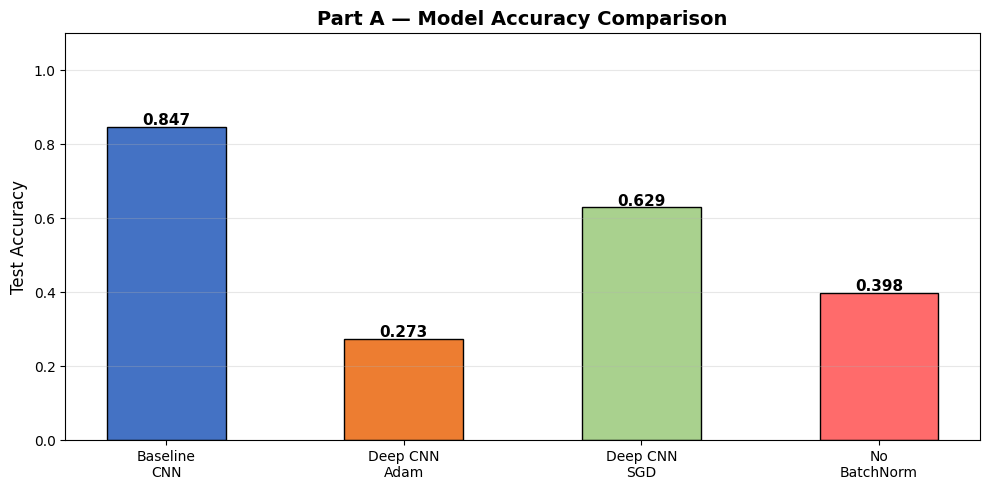

In [ ]:
print('\n' + '='*72)
print(f'{"Model":<30} {"Test Acc":>10} {"Test Loss":>10} {"Time (s)":>10}')
print('='*72)
rows = [
    ('Baseline CNN',          baseline_acc,  baseline_loss,  baseline_time),
    ('Deep CNN (Adam)',        deep_adam_acc, deep_adam_loss, deep_adam_time),
    ('Deep CNN (SGD)',         deep_sgd_acc,  deep_sgd_loss,  deep_sgd_time),
    ('Ablation (No BatchNorm)',ablation_acc,  ablation_loss,  ablation_time),
]
for name, acc, loss, t in rows:
    print(f'{name:<30} {acc:>10.4f} {loss:>10.4f} {t:>10.1f}')
print('='*72)

# Bar Chart
names  = ['Baseline\nCNN', 'Deep CNN\nAdam', 'Deep CNN\nSGD', 'No\nBatchNorm']
accs   = [baseline_acc, deep_adam_acc, deep_sgd_acc, ablation_acc]
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF6B6B']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Part A — Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('part_a_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 : Part B: Transfer Learning with VGG16

In [ ]:
# VGG16 requires 224x224 input and VGG-specific preprocessing
VGG_SIZE = (224, 224)

tl_train_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, validation_split=0.15
).flow_from_directory(
    BASE_DIR, target_size=VGG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

tl_val_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    validation_split=0.15
).flow_from_directory(
    BASE_DIR, target_size=VGG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)

tl_test_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
).flow_from_directory(
    TEST_DIR, target_size=VGG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print('Transfer Learning generators ready.')

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 620 images belonging to 4 classes.
Transfer Learning generators ready.


In [ ]:
# Build VGG16 Transfer Learning Model
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg.trainable = False   # Phase 1: freeze entire base

tl_model = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='VGG16_TL')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,452 (56.76 MB)

 Trainable params: 165,252 (645.52 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
# ── Phase 1: Feature Extraction (only train new head) ────────────────────────
print('Phase 1: Training classification head (VGG16 base frozen)...')
t0 = time.time()
history_tl_p1 = tl_model.fit(
    tl_train_gen, epochs=10,
    validation_data=tl_val_gen,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)
print(f'Phase 1 done in {time.time()-t0:.1f}s')

Phase 1: Training classification head (VGG16 base frozen)...
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 772ms/step - accuracy: 0.5451 - loss: 1.1613 - val_accuracy: 0.7123 - val_loss: 1.0633
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 583ms/step - accuracy: 0.7051 - loss: 0.7702 - val_accuracy: 0.8411 - val_loss: 0.4886
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 593ms/step - accuracy: 0.7426 - loss: 0.6426 - val_accuracy: 0.8110 - val_loss: 0.4914
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 595ms/step - accuracy: 0.7632 - loss: 0.5831 - val_accuracy: 0.8027 - val_loss: 0.5397
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 594ms/step - accuracy: 0.7781 - loss: 0.5413 - val_accuracy: 0.8274 - val_loss: 0.4594
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 581ms/step - accuracy: 0.7915 - loss: 0.5155 - val_accuracy: 0.8137 - val_loss: 0.4975
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 591ms/step - accuracy: 0.8088 - loss: 0.4713 - val_accuracy: 0.8219 - val_loss: 0.4892
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Phase 2: Fine-Tuning last 4 VGG16 layers
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

# Lower LR to avoid catastrophic forgetting
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)

print(f'Trainable layers: {sum(1 for l in tl_model.layers if l.trainable)}')
print('Phase 2: Fine-tuning last 4 VGG16 layers with lr=1e-5...')

t0 = time.time()
history_tl_p2 = tl_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1)
    ],
    verbose=1
)
tl_time = time.time() - t0
print(f'Phase 2 done in {tl_time:.1f}s')

Trainable layers: 8
Phase 2: Fine-tuning last 4 VGG16 layers with lr=1e-5...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 667ms/step - accuracy: 0.8377 - loss: 0.3964 - val_accuracy: 0.8603 - val_loss: 0.4185 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 601ms/step - accuracy: 0.8573 - loss: 0.3372 - val_accuracy: 0.8384 - val_loss: 0.4385 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 583ms/step - accuracy: 0.8655 - loss: 0.3221 - val_accuracy: 0.8356 - val_loss: 0.3937 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 595ms/step - accuracy: 0.8838 - loss: 0.2995 - val_accuracy: 0.8795 - val_loss: 0.3452 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 598ms/step - accuracy: 0.8847 - loss: 0.2820 - val_accuracy: 0.8329 - val_loss: 0.3998 - learning_rate: 1.0000e-05
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 599ms/step - accuracy: 0.8857 - loss: 0.2659 - val_accuracy: 0.8822 - val_loss: 0.3368 - learnin

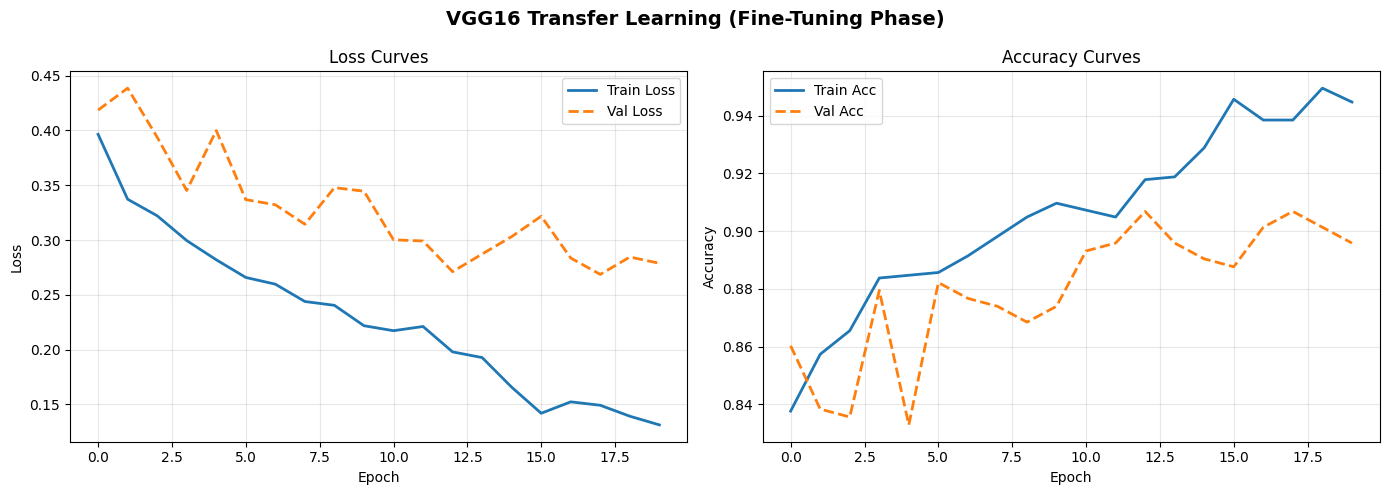


--- Bias-Variance Analysis ---
Final Train Accuracy : 0.9448
Final Val   Accuracy : 0.8959
Gap (Train - Val)    : 0.0489
>> GOOD FIT — train and val accuracy are close

VGG16 Transfer Learning
  Test Loss     : 0.3215
  Test Accuracy : 0.9065 (90.65%)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.87      0.90       181
meningioma_tumor       0.91      0.84      0.87       182
          normal       0.93      0.98      0.96        88
 pituitary_tumor       0.87      0.98      0.92       169

        accuracy                           0.91       620
       macro avg       0.91      0.92      0.91       620
    weighted avg       0.91      0.91      0.91       620



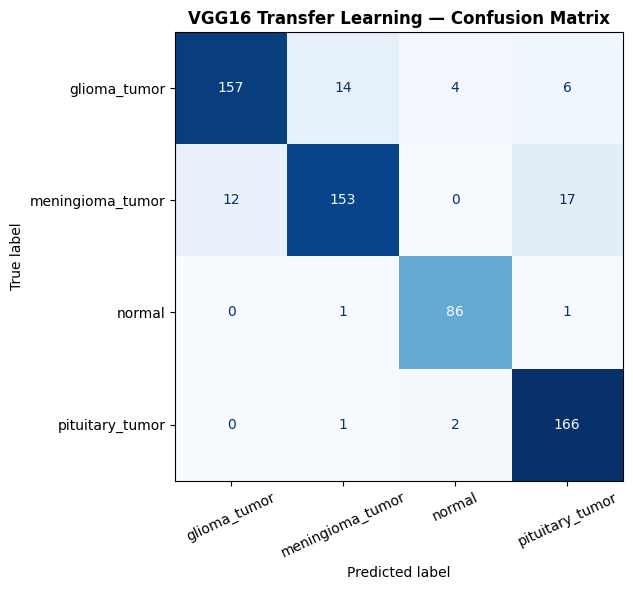

In [ ]:
plot_history(history_tl_p2, 'VGG16 Transfer Learning (Fine-Tuning Phase)', 'tl_history.png')
tl_loss, tl_acc = evaluate_model(tl_model, tl_test_gen, 'VGG16 Transfer Learning')

## Step 11: Final Summary: All Models


Model                                Test Accuracy  Test Loss
Baseline CNN (scratch)                      0.8468     0.5349
Deep CNN Adam (scratch)                     0.2726     1.7267
Deep CNN SGD (scratch)                      0.6290     0.8604
Ablation — No BatchNorm                     0.3984     1.3541
VGG16 Transfer Learning                     0.9065     0.3215


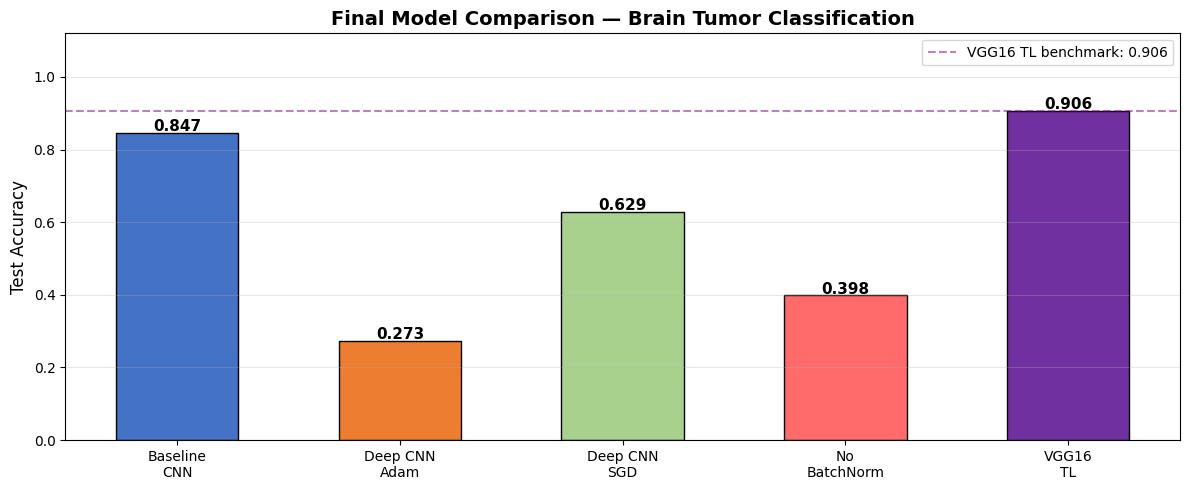

In [ ]:
print('\n' + '='*72)
print(f'{"Model":<35} {"Test Accuracy":>14} {"Test Loss":>10}')
print('='*72)
all_models = [
    ('Baseline CNN (scratch)',        baseline_acc,  baseline_loss),
    ('Deep CNN Adam (scratch)',        deep_adam_acc, deep_adam_loss),
    ('Deep CNN SGD (scratch)',         deep_sgd_acc,  deep_sgd_loss),
    ('Ablation — No BatchNorm',        ablation_acc,  ablation_loss),
    ('VGG16 Transfer Learning',        tl_acc,        tl_loss),
]
for name, acc, loss in all_models:
    print(f'{name:<35} {acc:>14.4f} {loss:>10.4f}')
print('='*72)

names_f  = ['Baseline\nCNN', 'Deep CNN\nAdam', 'Deep CNN\nSGD', 'No\nBatchNorm', 'VGG16\nTL']
accs_f   = [baseline_acc, deep_adam_acc, deep_sgd_acc, ablation_acc, tl_acc]
colors_f = ['#4472C4', '#ED7D31', '#A9D18E', '#FF6B6B', '#7030A0']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names_f, accs_f, color=colors_f, edgecolor='black', width=0.55)
for bar, acc in zip(bars, accs_f):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Final Model Comparison — Brain Tumor Classification',
             fontsize=14, fontweight='bold')
ax.axhline(y=tl_acc, color='purple', linestyle='--', alpha=0.5,
           label=f'VGG16 TL benchmark: {tl_acc:.3f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Discussion & Key Observations

### Part A : From Scratch CNNs (Actual Results)
- **Baseline CNN (84.68%)**: Best from-scratch model train/val gap only 3.16% **GOOD FIT**. Pituitary recall 99%.
- **Deep CNN Adam (27.26%)**: Failed val loss spiked to 3.87 at epoch 4. Learning rate 1e-3 too high for small dataset with BatchNorm.
- **Deep CNN SGD (62.90%)**: More stable than Adam but still 21.78% below baseline deeper is not always better on small datasets.
- **Ablation No BatchNorm (39.84%)**: Complete failure val accuracy stuck at 29%. Pituitary class never predicted. Proves BatchNorm is essential.

### Bias-Variance Analysis (Actual Results)
- Baseline CNN: gap = **3.16%**  Good Fit
- Deep CNN Adam: gap = **16.62%** High Variance (Overfitting)
- Deep CNN SGD: gap = **~10%** Moderate Variance
- VGG16 Transfer Learning: gap = **6.69%**  Good Fit

### Part B Transfer Learning VGG16 (Actual Results)
- **Phase 1** (frozen base): Converged to 84.66% val accuracy in 7 epochs using frozen ImageNet features.
- **Phase 2** (fine-tune last 4 layers, lr=1e-5): Reached **90.65% test accuracy**  all 4 classes above 80% precision and recall.
- Transfer learning outperformed best scratch model (84.68%) by **5.97 percentage points**.

### Challenges
- **Meningioma vs Glioma**: Most confused pair visually similar MRI textures across all models.
- **Deep CNN Adam**: Fix by reducing learning rate from 1e-3 to **1e-4** before rerunning.
- **Small dataset**: Only 2,475 training images  augmentation and class weights essential.
- **Training times**: Baseline 9.8 min, VGG16 ~13.34 min total on Colab T4 GPU.